<a href="https://colab.research.google.com/github/MdMukidurRahman/MdMukidurRahman/blob/main/Copy_of_Module_8_More_with_Exploring%2C_Plotting%2C_and_Modifying_Data_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overview**

This workbook will cover pp. 225-241 in Chapter 6 in our text. In this workbook you will learn more about datetime functions, a special function to loop over rows and columns (apply()), how to work with string/text columns (series), and how to edit data frames.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
#Import Simplified orders.csv file into Python and create data frame named df_orders
df_orders = pd.read_csv("/content/drive/My Drive/CIS530 Data/Simplified orders.csv")
#df_orders.head()

#Import Summarized orders.csv file into Python and create data frame named df_summarized_orders
df_summarized_orders = pd.read_csv("/content/drive/My Drive/CIS530 Data/Summarized orders.csv")
#df_summarized_orders.head()

#Import the Items file into Python and create a data frame named df_items
df_items = pd.read_csv("/content/drive/My Drive/CIS530 Data/Items.csv")

#Verify data frames were created successfully
#df_items.head()

#The data description for these three data frames are on pp. 171-172 of our text


***Datetime Columns (Chapter 6 section 7.5)***

In Chapter 5 we discussed how to ensure that our columns (series) were correctly formatted as dates using the **to_datetime()** function to convert a column to a date and the **dt.day_name()** function to extract the day of the week from a date column.

All datetime functions in **pandas** are accessed using the **dt** prefix, which stands for **d**ate**t**ime.

To learn more about datetime functions in pandas we are going to ask three business questions related to our case study data.

1. Are some weekdays busier than others when it comes to sales? Do we tend to observe more sales on weekdays than on weekends, or vice versa?

2. How do order patterns vary throughout the year? Do we find higher sales in the summer and a dip in the winter, or vice versa?

3. How can we find the amount of sales on any given day?

In [ ]:
#Recall the data type for each column in df_orders

df_orders.info()

#convert the DATETIME column to a date data type
df_orders.DATETIME = pd.to_datetime(df_orders['DATETIME'])

#examine the data types again
df_orders.info()

NameError: name 'pd' is not defined

**pandas** has many functions to work with dates to make your life easier. Some of the more useful ones are provided below.

**dt.weekday** returns the day of the week from Monday (0) to Sunday (6) in a numeric form.

**dt.day_name()** returns the name of the day of the week.

**dt.dayofyear** return the number of days since the start of the year.

**dt.weekofyear** has been depreciated since the writing of our text. To extract the number of weeks since the start of the year, use **isocalendar().week**

**dt.quarter** returns the quarter in which the date falls.

**dt.hour** returns the hour.

Using these functions can be useful to help you answer business questions related to your data. Let's see if we can answer our first question. Find the sales patterns for the different days of the week.

<Axes: xlabel='DATETIME'>

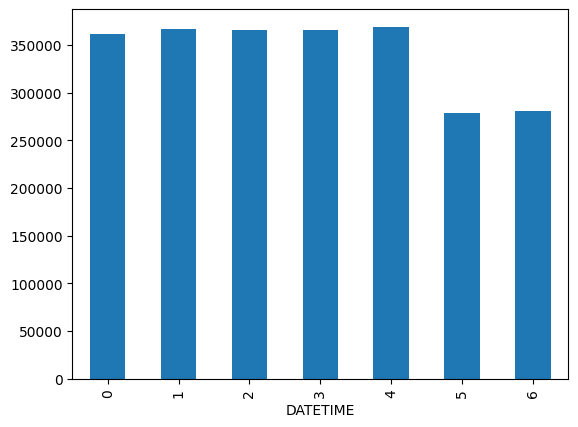

In [ ]:
#Create bar chart with the number orders by each day of the week
df_orders.DATETIME.dt.weekday.value_counts().sort_index().plot(kind="bar")

Let's consider the second question. Do orders tend to peak in the summer?

<Axes: xlabel='week'>

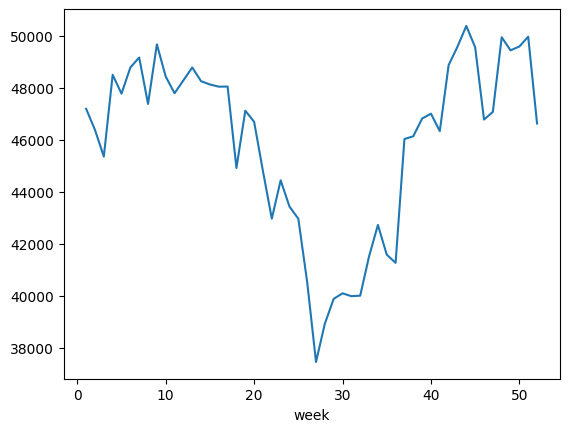

In [ ]:
#construct a line chart that displays sales for each week of the year
df_orders.DATETIME.dt.isocalendar().week.value_counts().sort_index().plot(kind="line")

***String Columns (Chapter 6 section 7.6)***

Earlier in the class we discussed how you could perform certain operations on strings in Python. We are now going to extend this concept to operating on columns (series) in **pandas** data frames.

In a similar manner how all the date functions are accessed with **dt** keyword, all the string functions are accessed with the **str** function.

A few helpful functions are as follows:
**str.contains()** checks to see if a string contains a substring. The function is case sensitive.

Using the square brackets **[ , ]** after the **str** keyword (**str[ , ]**) will allow you to extract a certain number of characters from a string series (column). The first argument is the position of where you want to start in the string (remember, everyhting in Python is zero-indexed) and the second argument is the position in the string where you want to end. The ending position is ***exclusive***, meaning the number you specify ***will not be included***.

The **split()** function is handy for parsing strings and breaking them into smaller parts based on your analytical needs.

By default, **split()** identifies spaces (whitespace) as the delimiter and slices the string accordingly. The function returns a list of “words” that were initially separated by the delimiter in the original string.

You can specify a custom delimiter (e.g., a comma or hyphen) using the separator argument.

The next few examples will use the **df_items** data frame.

In [ ]:
#uppercase all the letters for the ITEM_NAME series (column)
df_items.ITEM_NAME.str.upper().head()

#lowercase all the letters for the items that contain lemon in their name
df_items.ITEM_NAME.str.lower().str.contains('LEMON').head()
#items that contain lemon in their name
df_items.ITEM_NAME.str.lower().str.contains('LEMON').head().sum()

#extract the first three characters of the ITEM_NAME column
df_items.ITEM_NAME.str[0:3].head()

#extract the last three characters of the ITEM_NAME column
df_items.ITEM_NAME.str[-3:].head()

#This functionality can be useful for data quality checks.
#Each order should start with an "O". You can verfiy this.
df_orders.ORDER_ID.str[0:1].value_counts()

#Suppose you wanted to separate every word in the ITEM_NAME series (column)
#into a list of words
df_items.ITEM_NAME.str.split().head()

#You can then access each individual word with str[] functionality
df_items.ITEM_NAME.str.split().str[0].head()

,ITEM_NAME
0,Farro
1,Spindrift
2,Classic
3,Kombucha
4,Cauliflower


***The apply() function (Chapter 6 section 7.7)***

The **apply()** function takes any function you define and applies it row by row, to an entire series (column).

The **apply()** function is almost as slow as the native (base) Python functions. Only use **apply()** when you have to write a speciality function, that is, there is no **pandas** function available to perform the analytical task you need.

In [ ]:
#Find whether each order was placed at the Columbia restaurant
#RESTAURANT_ID=R1001 corresponds to the Columbia restaurant
#filtering method
(df_orders.RESTAURANT_ID == 'R1001').head()

#Suppose instead of filtering you complete this task witha a function called is_columbia()
#The function should return True if the restaurant is Columbia, False otherwise
def is_columbia(restaurant_id):
  return restaurant_id == 'R10001'

#call the function
is_columbia('R10005')



#Apply the is_columbia() function to every row in the df_orders data frame
df_orders.RESTAURANT_ID.apply(is_columbia).head()


,RESTAURANT_ID
0,False
1,False
2,True
3,False
4,False


***More with apply()***

The **apply()** function takes several arguments. The first argument is the name of the function you want to apply.

You can apply a function to an entire data frame, either all the rows or all the columns using the **axis=** argument.

If **axis=1** the function will loop through every row.

If **axis=0** the function will loop through every column.



In [ ]:

#create a function to add the number of cookies and drinks in each order
def total_extras(row):
  return row.COOKIES + row.DRINKS

#apply the function to the df_orders data frame
#df_orders.apply(total_extras, axis=1).head()

In [ ]:

#Use built-in pandas functions to add the number of cookies and drinks in each order
df_orders.COOKIES + df_orders.DRINKS

#use apply()function to add number of cookies and drinks in each order
df_orders.apply(total_extras, axis=1).head()


,0
0,3.0
1,0.0
2,2.0
3,1.0
4,0.0


***Editing Data frames (Chapter 6 section 8)***

So far we have been operating on existing data frames. We have thus far not discussed anything related to editing an existing data frames.

We will go through a few examples of how to edit existing data frames.

***Adding Columns (Chatper 6 section 8.10)***

To add a column you can use the square bracket notation similar to when you reference a column. The dot notation (.) will not work for adding a column.


In [ ]:
#Add a column to the df_orders table to indicate whether an order contains a drink or not

#delete this and insert your code here

#Try to add the column using the dot (.) notation
#df_orders.HAS_DRINK = df_orders.DRINKS > 0

***Removing Columns***

The **drop()** function along with the name of the column will remove the column.

In [ ]:
#Remove the HAS_DRINK column
#delete this and insert your code here

***Editing Specific Values in a Data Frame; loc[]***

How do you edit specific values in a data frame (the equivalent of typing in a cell in Excel)?

Let's motivate the answer to this question by completing a specific analytical task.

You want to add a column to the df_summarized_orders data frame named ORDER_VOLUME that contains the value "LOW" if under 600 orders were placed, "MEDIUM" if between 600 and 1200 orders were placed, and "HIGH" otherwise.

One approach:

1. Create a column that contains the word "HIGH".
2. Replace the values in that column with the word "MEDIUM" for all days with fewer than 1200 orders.
3. Replace the values in that column with the word "LOW" for all days with fewer than 600 orders.

You want to filter and change a data frame at the same time. In pandas the **loc** keyword allows you to filter and change/modify a data frame at the same time.

To use the **loc** keyword, use square brackets, specify the rows you want to filter by (in the same way when you filter a data frame), followed by a comma, and the specify the name of the column you want to edit.

Let's implement this procedure in code.

In [ ]:
#Create the ORDER_VOLUME column
#Step 1
df_summarized_orders['ORDER_VOLUME'] = 'HIGH'

#Step 2
df_summarized_orders.loc[df_summarized_orders.NUM_ORDERS < 1200, 'ORDER_VOLUME'] = 'MEDIUM'

#Step 2 -
df_summarized_orders.loc[df_summarized_orders.NUM_ORDERS < 600, 'ORDER_VOLUME'] = 'LOW'

#Step 3
df_summarized_orders.head()

#examine ORDER_VOLUME column





,RESTAURANT_NAME,day,NUM_ORDERS,PERC_DELIVERY,ORDER_VOLUME
0,Bryant Park,1/1/2018,373,0.0,LOW
1,Bryant Park,1/2/2018,789,0.0,MEDIUM
2,Bryant Park,1/3/2018,818,0.0,MEDIUM
3,Bryant Park,1/4/2018,782,0.0,MEDIUM
4,Bryant Park,1/5/2018,719,0.0,MEDIUM
